In [ ]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
CIFAR10=tf.keras.datasets.cifar10
(train_images,train_labels),(test_images,test_labels)=CIFAR10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


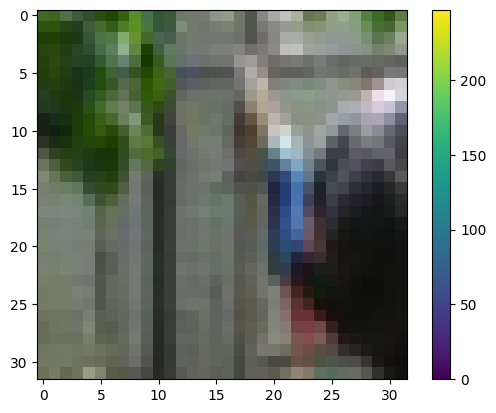

In [ ]:
import matplotlib.pyplot as plt
data_idx=544
plt.figure()
plt.imshow(train_images[data_idx])
plt.colorbar()
plt.grid(False)
plt.show()

In [ ]:
train_labels[data_idx]

array([2], dtype=uint8)

<function matplotlib.pyplot.show(close=None, block=None)>

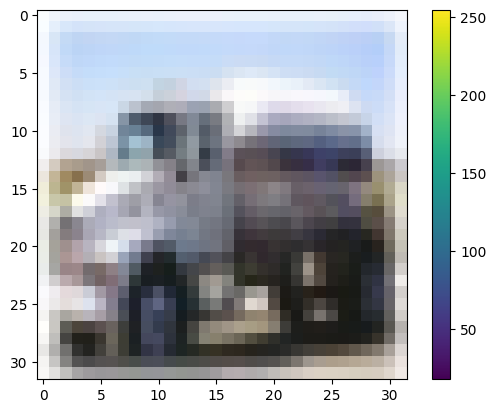

In [ ]:
import matplotlib.pyplot as plt
data_idx=5997
plt.figure()
plt.imshow(train_images[data_idx])
plt.colorbar()
plt.grid(False)
plt.show

In [ ]:
train_labels[data_idx]

array([9], dtype=uint8)

array([[[190, 185, 181],
        [188, 183, 179],
        [188, 183, 179],
        ...,
        [193, 196, 193],
        [193, 195, 192],
        [191, 194, 190]],

       [[193, 188, 184],
        [192, 187, 183],
        [192, 187, 183],
        ...,
        [194, 196, 192],
        [194, 196, 192],
        [192, 194, 191]],

       [[191, 186, 182],
        [191, 186, 182],
        [192, 187, 183],
        ...,
        [192, 193, 188],
        [192, 193, 188],
        [190, 191, 187]],

       ...,

       [[206, 173, 130],
        [206, 173, 130],
        [207, 174, 131],
        ...,
        [214, 182, 142],
        [214, 182, 142],
        [214, 182, 142]],

       [[207, 174, 134],
        [207, 174, 134],
        [207, 174, 134],
        ...,
        [216, 184, 142],
        [216, 185, 142],
        [216, 184, 143]],

       [[195, 164, 126],
        [195, 163, 126],
        [192, 160, 122],
        ...,
        [213, 183, 139],
        [214, 183, 139],
        [213, 182, 139]]], dtype=uint8)
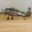

In [ ]:
test_images[data_idx]

In [ ]:
number_of_classes=train_labels.max() +1
number_of_classes

np.uint8(10)

In [ ]:
import tensorflow as tf

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # Freeze pretrained layers

model = tf.keras.Sequential([
    tf.keras.layers.Resizing(224, 224),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(number_of_classes, activation='softmax')
])


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
image_height=32
image_width=32
channels=3
number_of_weights=image_height * image_width * channels * number_of_classes.item()
number_of_weights

30720

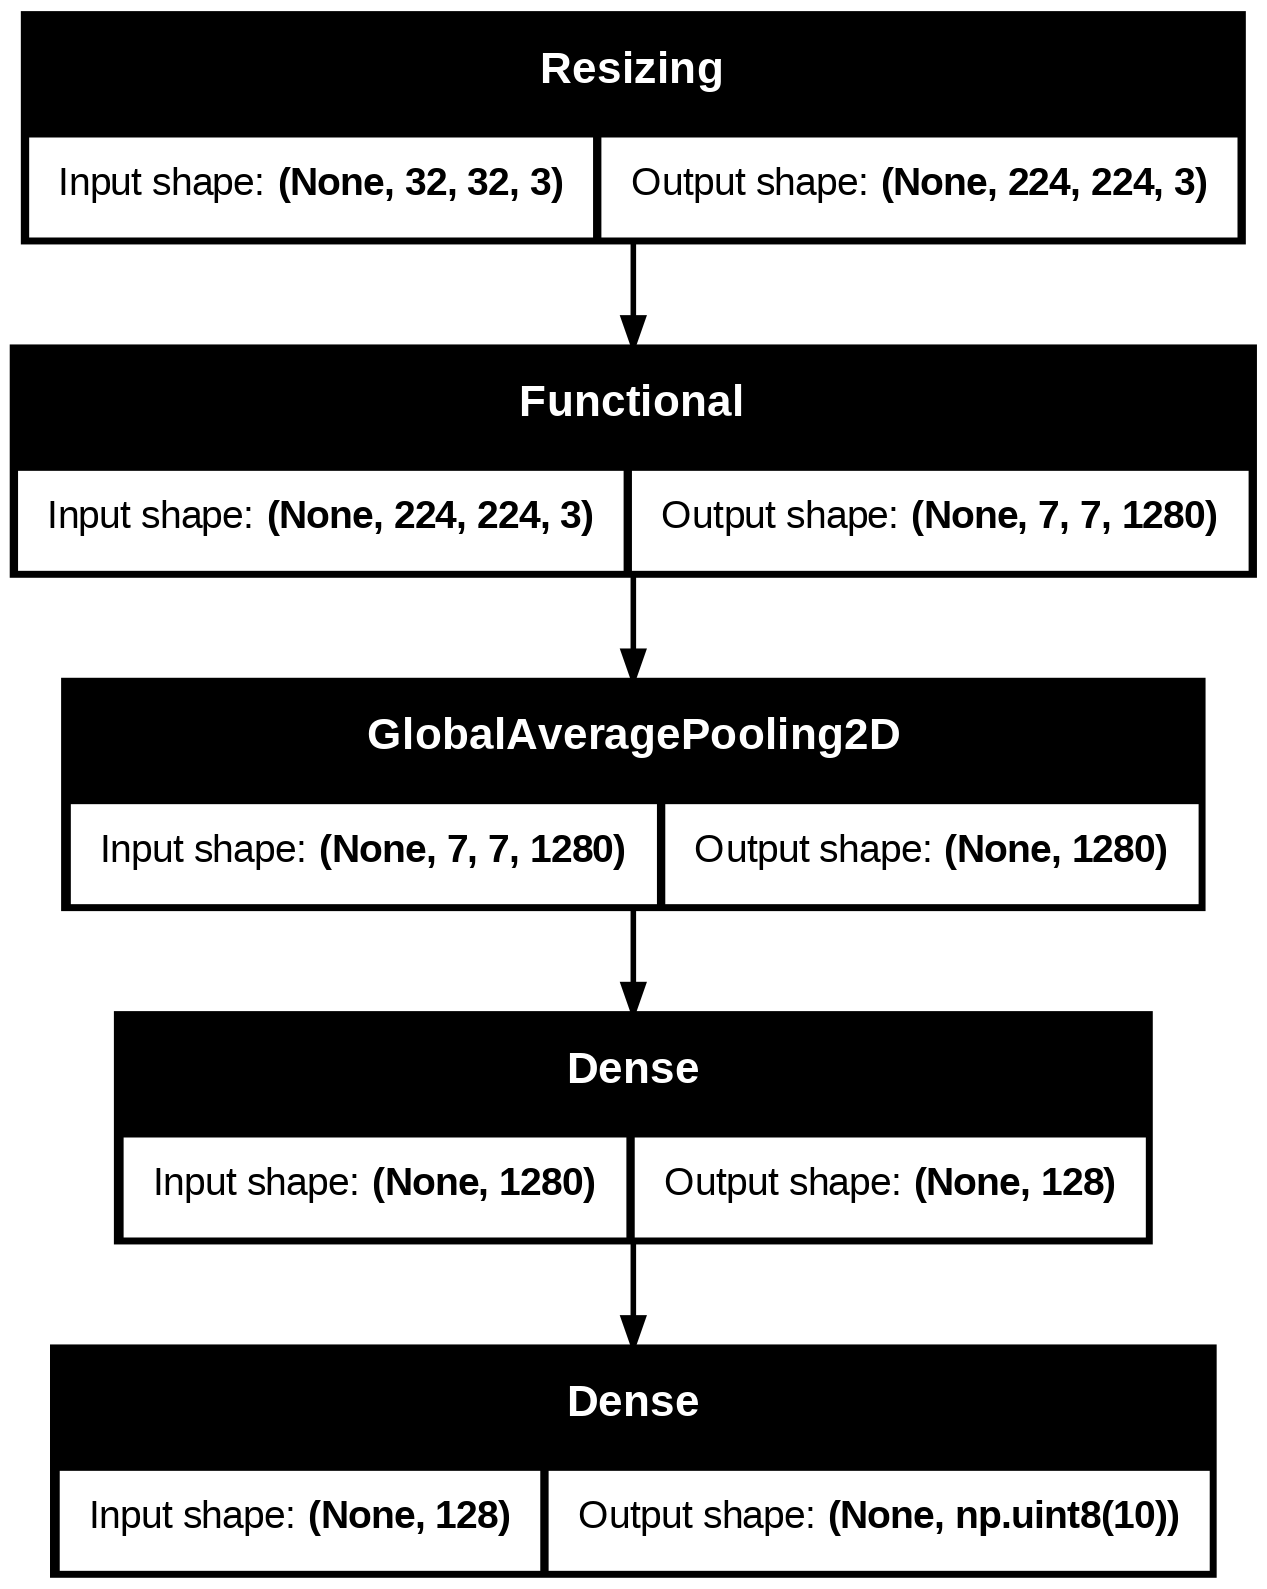

In [ ]:
model.build(input_shape=(None, 32, 32, 3))
tf.keras.utils.plot_model(model, show_shapes=True)

In [ ]:
model.compile(optimizer='adam',
loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
metrics=['accuracy'])

In [ ]:
history = model.fit(
    train_images,
    train_labels,
    epochs=15,
    verbose=True,
    validation_data=(test_images, test_labels)
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 114s 55ms/step - accuracy: 0.8300 - loss: 0.5087 - val_accuracy: 0.8935 - val_loss: 0.3118
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 37ms/step - accuracy: 0.9007 - loss: 0.2788 - val_accuracy: 0.9016 - val_loss: 0.2942
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.9152 - loss: 0.2386 - val_accuracy: 0.9088 - val_loss: 0.2701
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.9280 - loss: 0.2113 - val_accuracy: 0.9068 - val_loss: 0.2708
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.9361 - loss: 0.1837 - val_accuracy: 0.9095 - val_loss: 0.2770
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.9411 - loss: 0.1671 - val_accuracy: 0.9054 - val_loss: 0.2962
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.9479 - loss: 0.1468 - val_accuracy: 0.9093 - val_loss: 0.2828
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.9514 - loss: 0.1

In [ ]:
model.predict(train_images[0:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


array([[1.40810384e-11, 7.44365403e-10, 4.48472507e-04, 3.37799406e-03,
        4.61723992e-08, 1.81364539e-05, 9.96155322e-01, 2.51468069e-09,
        3.89677145e-11, 4.82242968e-10],
       [6.11463571e-13, 2.47666634e-08, 4.43752240e-13, 1.64919554e-12,
        5.66222252e-18, 5.33775769e-13, 9.92221700e-16, 1.14882223e-14,
        1.33730345e-11, 1.00000000e+00],
       [8.49757195e-02, 2.65091185e-05, 2.65132781e-04, 2.42662259e-06,
        3.64094230e-05, 2.94670343e-07, 3.73346097e-07, 1.90460810e-03,
        1.65240504e-02, 8.96264493e-01],
       [1.50442978e-10, 3.34114659e-12, 1.06677362e-07, 4.82049472e-07,
        9.99994636e-01, 3.20439369e-07, 7.57267458e-07, 3.64713765e-06,
        5.10232800e-10, 1.05062501e-08],
       [5.32470210e-07, 9.99999046e-01, 1.66489554e-12, 3.30985933e-12,
        3.29811872e-12, 4.63014488e-11, 2.73515238e-10, 9.08744705e-13,
        5.30461675e-09, 5.24495590e-07],
       [4.77215483e-14, 9.99999881e-01, 3.87835634e-15, 9.18711201e-12,
   

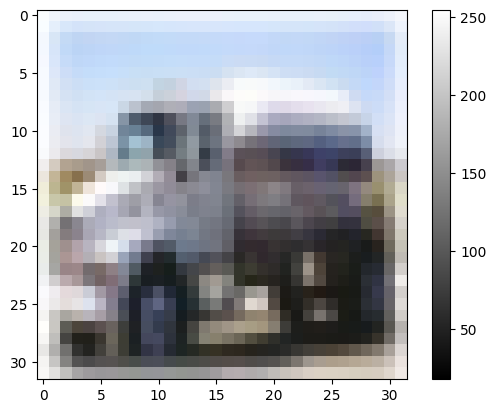

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


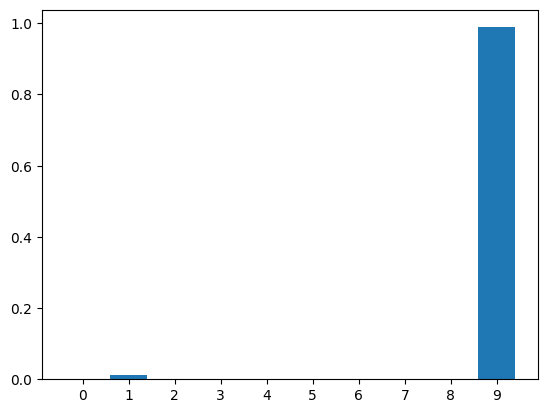

correct answer: [9]


In [ ]:
ata_idx = 8875

plt.figure()
plt.imshow(train_images[data_idx], cmap='gray')
plt.colorbar()
plt.grid(False)
plt.show()

x_values = range(number_of_classes)
plt.figure()
plt.bar(x_values, model.predict(train_images[data_idx:data_idx+1]).flatten())
plt.xticks(range(10))
plt.show()

print("correct answer:", train_labels[data_idx])